In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

# Unlocking YouTube Channel Performance Secrets

## Objective

This project analyzes YouTube channel performance data to identify:
- growth patterns
- engagement factors
- monetization drivers
- subscriber growth trends

The analysis combines:
- Exploratory Data Analysis (EDA)
- Revenue Analytics
- Engagement Analysis
- Machine Learning Prediction

to uncover actionable insights that improve channel performance.

In [2]:
df = pd.read_csv("youtube_channel_real_performance_analytics.csv")

df.head()

,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201.0,2016-06-02 00:00:00,0,2,6,2016,Thursday,0.024,723.0,...,0.0,0.0,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66
1,1,391.0,2016-06-10 00:00:00,8,10,6,2016,Friday,0.056,727.0,...,0.0,0.0,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85
2,2,133.0,2016-06-14 00:00:00,4,14,6,2016,Tuesday,0.014,76.0,...,0.0,0.0,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07
3,3,14.0,2016-06-29 00:00:00,15,29,6,2016,Wednesday,0.004,18.0,...,0.0,0.0,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60
4,4,45.0,2016-07-01 00:00:00,2,1,7,2016,Friday,0.000,0.0,...,0.0,0.0,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62


In [4]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (364, 70)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 70 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  364 non-null    int64  
 1   Video Duration                      364 non-null    float64
 2   Video Publish Time                  364 non-null    object 
 3   Days Since Publish                  364 non-null    int64  
 4   Day                                 364 non-null    int64  
 5   Month                               364 non-null    int64  
 6   Year                                364 non-null    int64  
 7   Day of Week                         364 non-null    object 
 8   Revenue per 1000 Views (USD)        364 non-null    float64
 9   Monetized Playbacks (Estimate)      364 non-null    float64
 10  Playback-Based CPM (USD)            364 non-null    float64
 11  CPM (USD)                           364 non-n

In [6]:
df.describe()

,ID,Video Duration,Days Since Publish,Day,Month,Year,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),Playback-Based CPM (USD),CPM (USD),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
count,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,...,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000,3.640000e+02,364.000000
mean,181.500000,664.239011,8.406593,15.807692,6.642857,2018.736264,0.112283,8934.711538,1.553734,1.059005,...,0.824176,0.008242,45.970989,285.612637,128800.101648,10058.965455,321.024725,8.852052,9.595286e+05,7.914615
std,105.221988,330.646183,15.371239,8.924004,3.421521,2.530629,0.179668,12967.843236,1.078549,0.728380,...,9.053369,0.090534,12.457470,116.595678,118209.844270,9516.160361,444.594763,13.414650,1.180519e+06,2.903383
min,0.000000,9.000000,0.000000,1.000000,1.000000,2016.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,15.050000,8.000000,2461.000000,12.697900,-3.000000,0.000000,3.222800e+04,0.620000
25%,90.750000,496.000000,3.000000,8.000000,4.000000,2017.000000,0.015000,349.500000,0.817750,0.522000,...,0.000000,0.000000,40.252500,233.750000,27160.500000,2759.404250,41.000000,0.443250,1.317082e+05,6.420000
50%,181.500000,613.000000,5.000000,16.000000,7.000000,2018.000000,0.050000,3564.000000,1.540500,1.155500,...,0.000000,0.000000,45.465000,286.500000,101950.500000,8102.962950,180.000000,4.285000,6.204065e+05,8.395000
75%,272.250000,786.500000,9.000000,23.000000,10.000000,2021.000000,0.143500,13579.250000,2.025250,1.458750,...,0.000000,0.000000,51.010000,344.250000,198169.500000,14084.498550,421.250000,11.476250,1.368464e+06,9.920000
max,363.000000,2311.000000,260.000000,31.000000,12.000000,2024.000000,1.600000,100566.000000,7.385000,6.295000,...,100.000000,1.000000,117.300000,776.000000,670990.000000,53794.658700,3728.000000,103.117000,1.270226e+07,27.660000


In [7]:
df.isnull().sum()

ID                         0
Video Duration             0
Video Publish Time         0
Days Since Publish         0
Day                        0
                          ..
Watch Time (hours)         0
Subscribers                0
Estimated Revenue (USD)    0
Impressions                0
Video Thumbnail CTR (%)    0
Length: 70, dtype: int64

In [8]:
# remove duplicates
df.drop_duplicates(inplace=True)

# fill missing values
df.fillna(0, inplace=True)

print("Cleaned Shape:", df.shape)

Cleaned Shape: (364, 70)


In [9]:
# Engagement Rate
df['Engagement Rate (%)'] = (
    (df['Likes'] + df['Shares']) / df['Views']
) * 100

# Revenue Per Watch Hour
df['Revenue Per Watch Hour'] = (
    df['Estimated Revenue (USD)'] /
    df['Watch Time (hours)']
)

# Subscriber Conversion Rate
df['Subscriber Conversion Rate (%)'] = (
    df['New Subscribers'] / df['Views']
) * 100

In [10]:
kpi_summary = {
    "Total Revenue": round(df['Estimated Revenue (USD)'].sum(), 2),
    "Total Views": int(df['Views'].sum()),
    "Total Watch Time": round(df['Watch Time (hours)'].sum(), 2),
    "Average CTR": round(df['Video Thumbnail CTR (%)'].mean(), 2),
    "Total Subscribers Gained": int(df['New Subscribers'].sum())
}

kpi_summary

{'Total Revenue': np.float64(3222.15),
 'Total Views': 46883237,
 'Total Watch Time': np.float64(3661463.43),
 'Average CTR': np.float64(7.91),
 'Total Subscribers Gained': 127375}

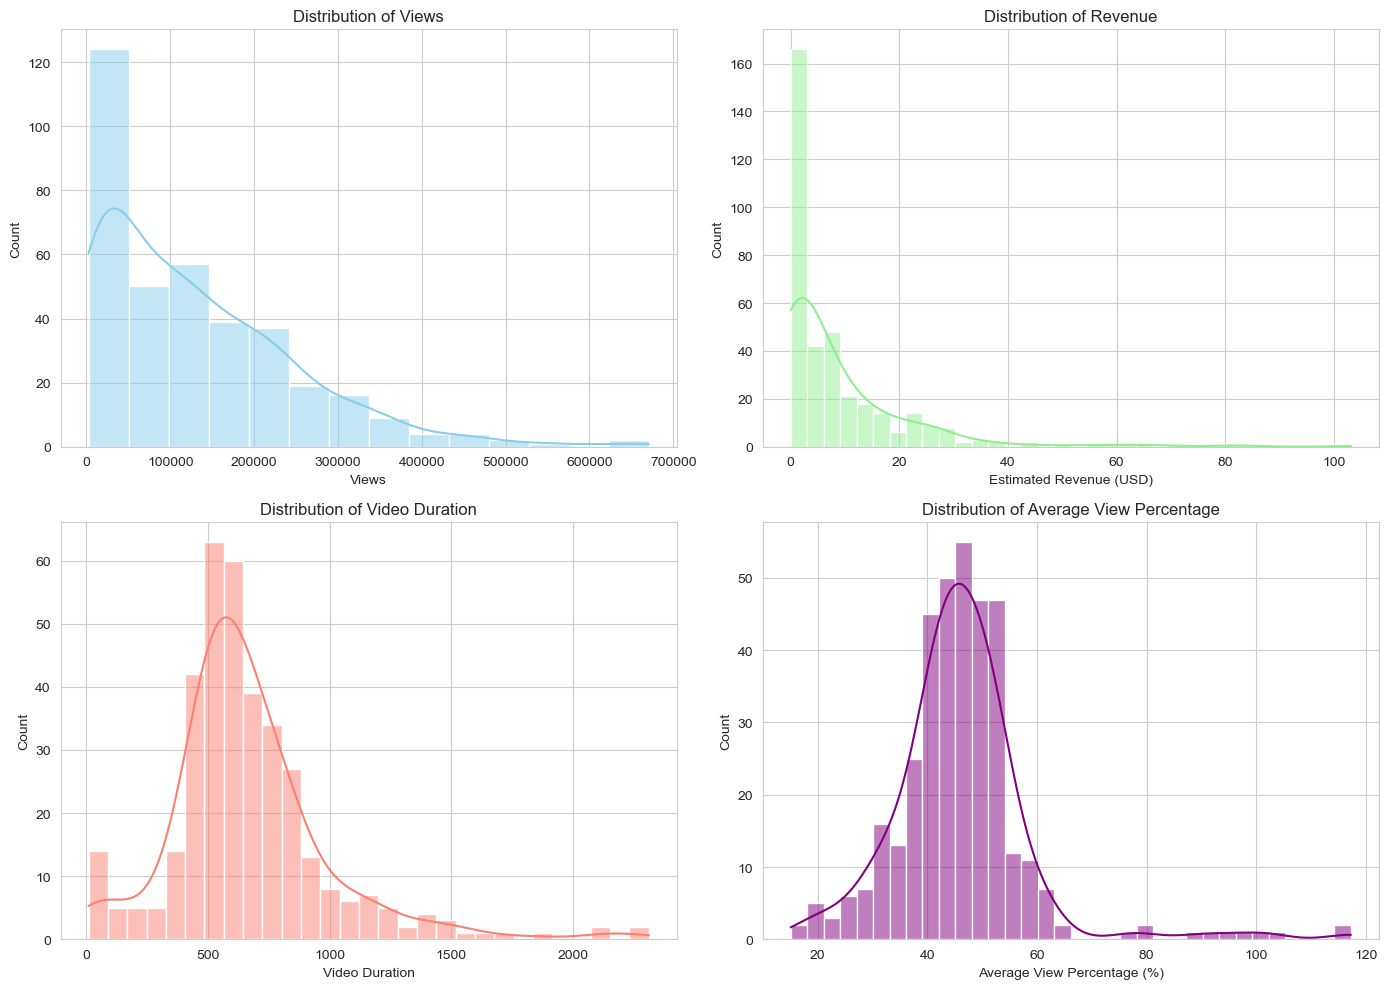

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.histplot(df['Views'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title("Distribution of Views")

sns.histplot(df['Estimated Revenue (USD)'], kde=True, ax=axes[0,1], color='lightgreen')
axes[0,1].set_title("Distribution of Revenue")

sns.histplot(df['Video Duration'], kde=True, ax=axes[1,0], color='salmon')
axes[1,0].set_title("Distribution of Video Duration")

sns.histplot(df['Average View Percentage (%)'], kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title("Distribution of Average View Percentage")

plt.tight_layout()
plt.show()

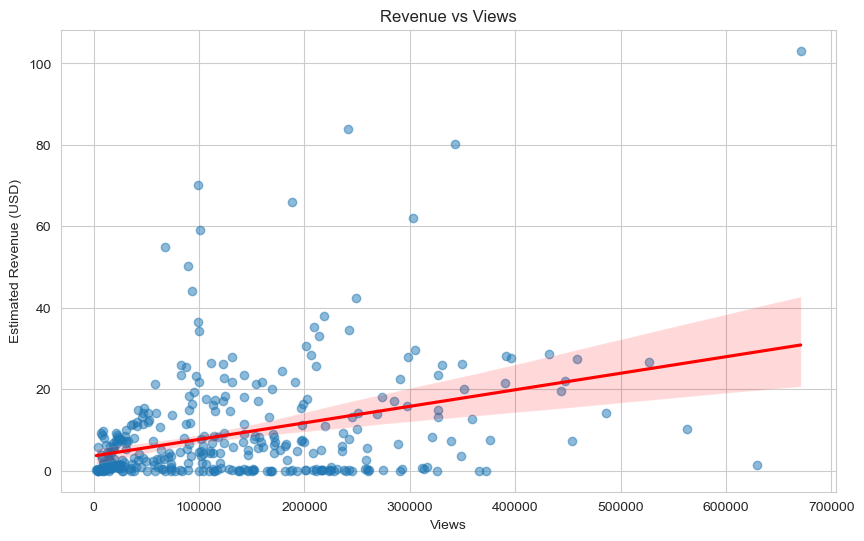

In [12]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='Views',
    y='Estimated Revenue (USD)',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title("Revenue vs Views")
plt.show()

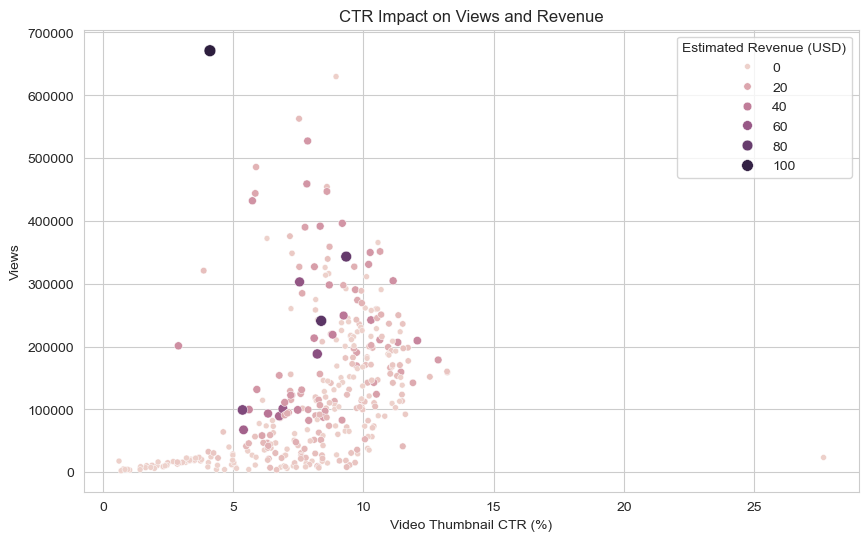

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Video Thumbnail CTR (%)',
    y='Views',
    hue='Estimated Revenue (USD)',
    size='Estimated Revenue (USD)'
)

plt.title("CTR Impact on Views and Revenue")
plt.show()

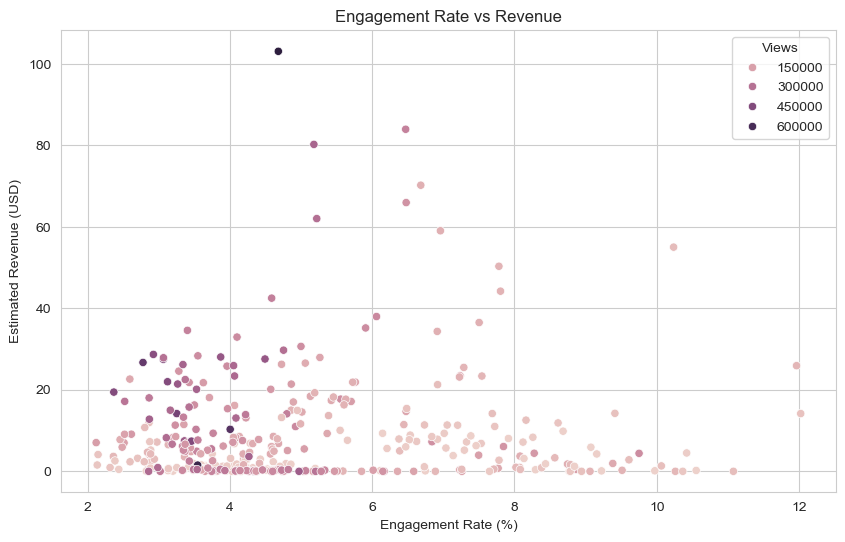

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Engagement Rate (%)',
    y='Estimated Revenue (USD)',
    hue='Views'
)

plt.title("Engagement Rate vs Revenue")
plt.show()

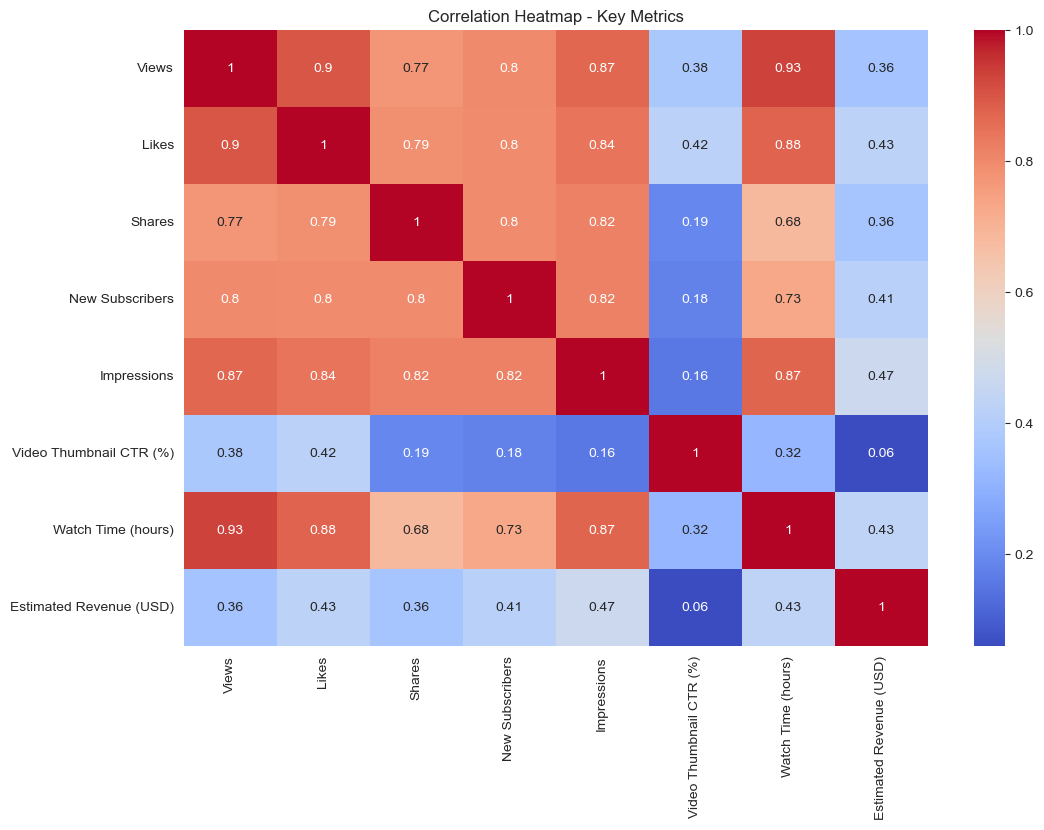

In [15]:
corr_columns = [
    'Views',
    'Likes',
    'Shares',
    'New Subscribers',
    'Impressions',
    'Video Thumbnail CTR (%)',
    'Watch Time (hours)',
    'Estimated Revenue (USD)'
]

plt.figure(figsize=(12,8))

sns.heatmap(
    df[corr_columns].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap - Key Metrics")

plt.show()

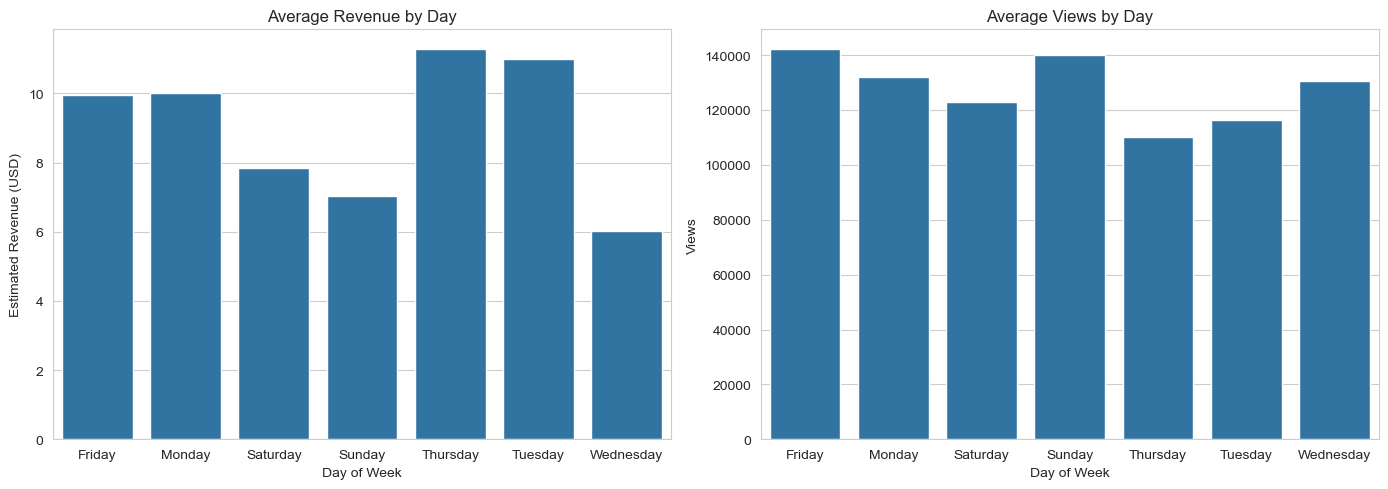

In [16]:
dow_stats = df.groupby('Day of Week').agg({
    'Estimated Revenue (USD)': 'mean',
    'Views': 'mean'
}).reset_index()

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.barplot(
    data=dow_stats,
    x='Day of Week',
    y='Estimated Revenue (USD)',
    ax=axes[0]
)

axes[0].set_title("Average Revenue by Day")

sns.barplot(
    data=dow_stats,
    x='Day of Week',
    y='Views',
    ax=axes[1]
)

axes[1].set_title("Average Views by Day")

plt.tight_layout()
plt.show()

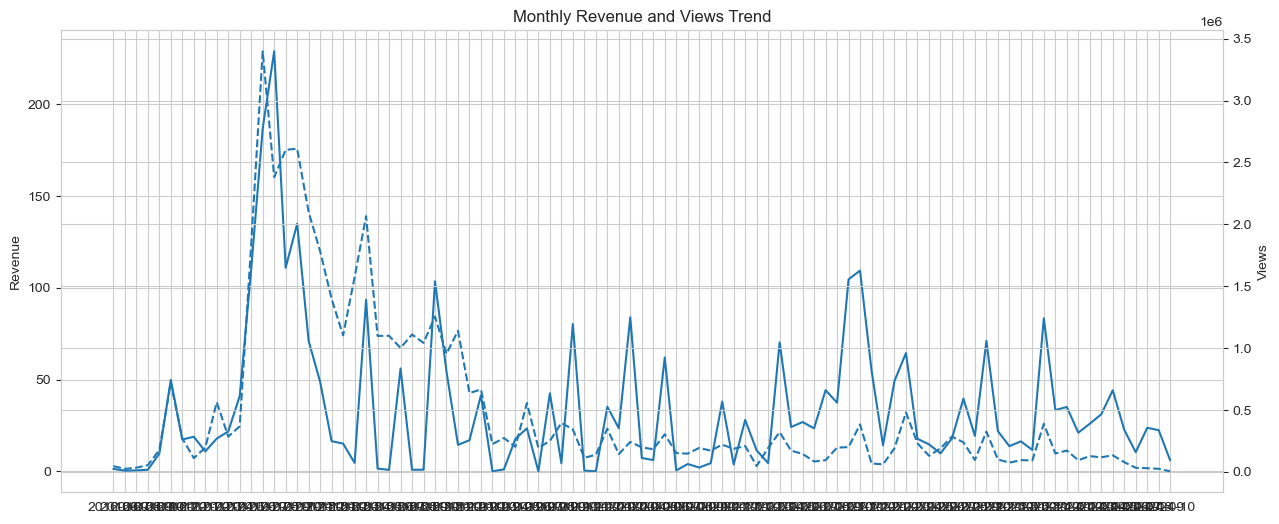

In [19]:
df['Video Publish Time'] = pd.to_datetime(df['Video Publish Time'])

monthly = df.groupby(df['Video Publish Time'].dt.to_period('M')).agg({
    'Estimated Revenue (USD)': 'sum',
    'Views': 'sum'
})

monthly.index = monthly.index.astype(str)

fig, ax1 = plt.subplots(figsize=(15,6))

ax1.plot(monthly.index, monthly['Estimated Revenue (USD)'])
ax1.set_ylabel("Revenue")

ax2 = ax1.twinx()

ax2.plot(monthly.index, monthly['Views'], linestyle='dashed')
ax2.set_ylabel("Views")

plt.xticks(rotation=45)

plt.title("Monthly Revenue and Views Trend")

plt.show()

# Machine Learning Revenue Prediction

A Random Forest Regressor model was used to predict YouTube revenue based on:
- views
- watch time
- impressions
- engagement
- CTR
- monetization metrics

The objective is to identify the strongest factors influencing revenue generation.

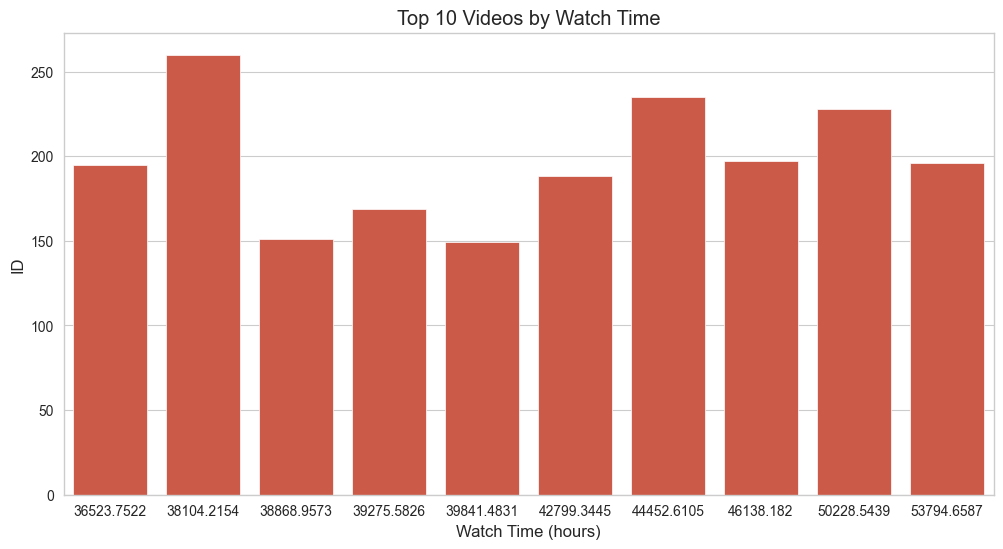

In [35]:
top_watch = df.sort_values(
    by='Watch Time (hours)',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_watch['Watch Time (hours)'],
    y=top_watch['ID']
)

plt.title("Top 10 Videos by Watch Time")

plt.show()

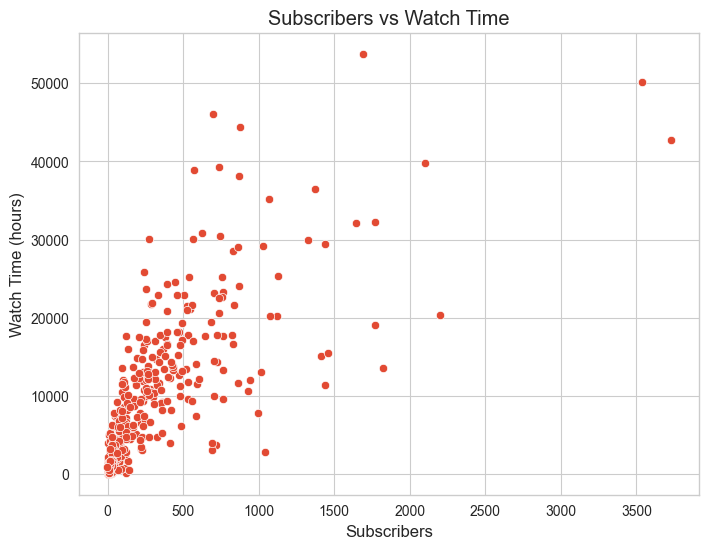

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Subscribers'],
    y=df['Watch Time (hours)']
)

plt.title("Subscribers vs Watch Time")

plt.show()

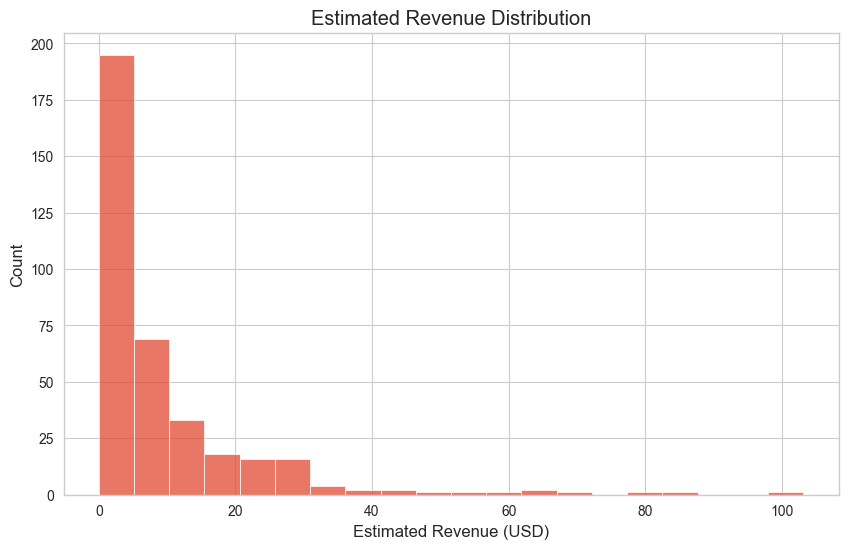

In [37]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Estimated Revenue (USD)'],
    bins=20
)

plt.title("Estimated Revenue Distribution")

plt.show()

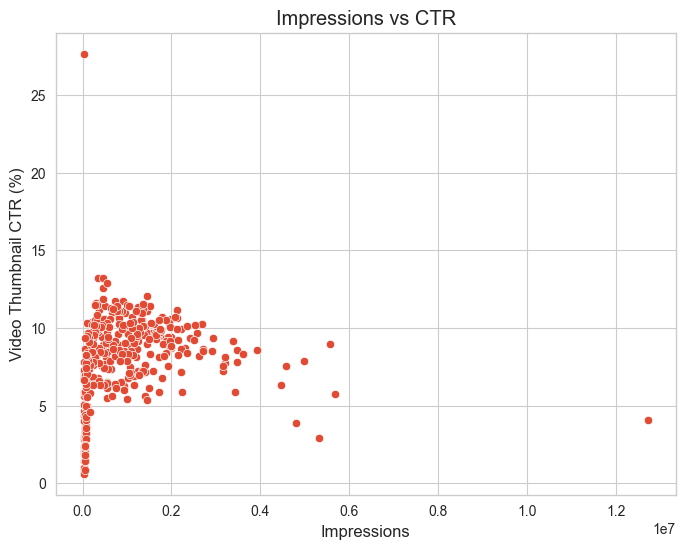

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Impressions'],
    y=df['Video Thumbnail CTR (%)']
)

plt.title("Impressions vs CTR")

plt.show()

In [20]:
features = [
    'Views',
    'Likes',
    'Shares',
    'Impressions',
    'Video Thumbnail CTR (%)',
    'Watch Time (hours)',
    'Ad Impressions',
    'Monetized Playbacks (Estimate)'
]

X = df[features]

y = df['Estimated Revenue (USD)']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [23]:
y_pred = model.predict(X_test)

In [24]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2.1298356164383576
RMSE: 3.811118090161492
R2 Score: 0.8331774496700386


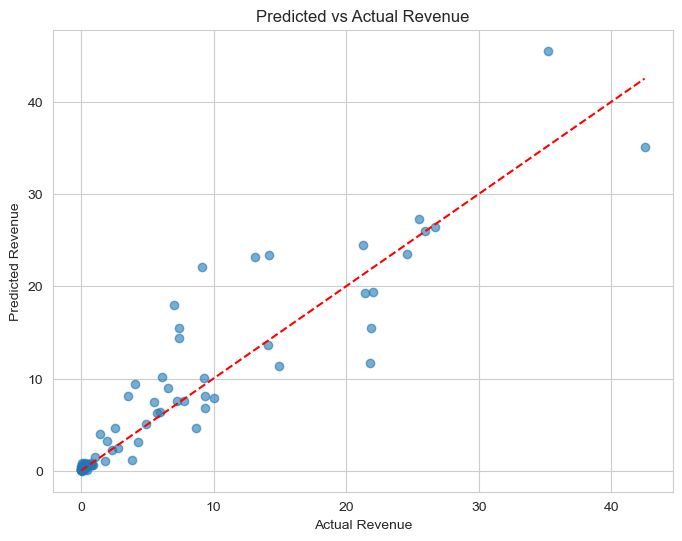

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='dashed',
    color='red'
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title("Predicted vs Actual Revenue")

plt.show()

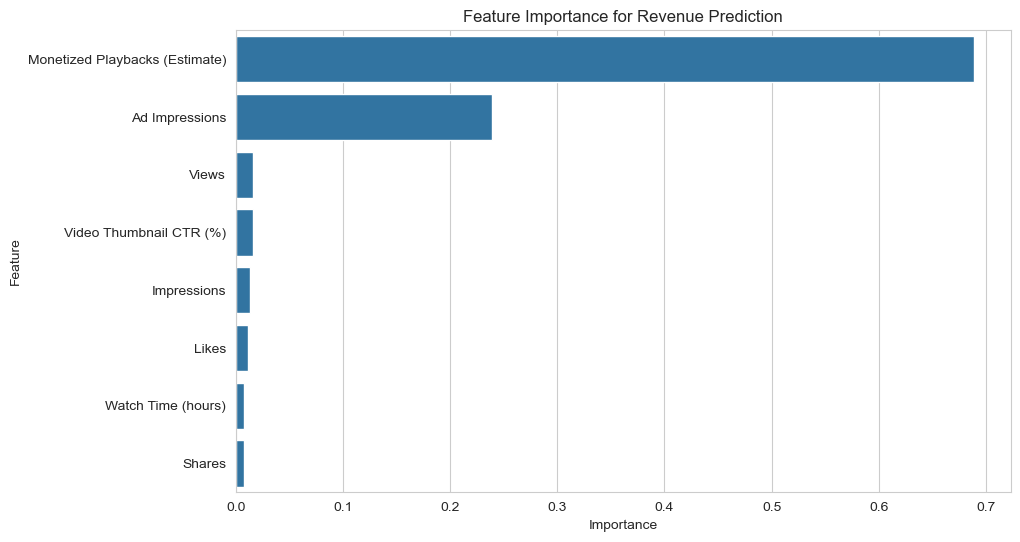

In [26]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance for Revenue Prediction")

plt.show()

Insight 1

Videos with higher watch time generally generate more revenue.

Insight 2

Higher thumbnail CTR improves impressions conversion.

Insight 3

Subscriber growth positively impacts monetization.

Insight 4

Ad impressions strongly influence AdSense revenue.

Insight 5

Consistent publishing contributes to audience engagement and revenue growth.

FINAL CONCLUSION

# Conclusion

This analysis successfully identified the major factors influencing YouTube channel growth and revenue generation.

The project combined:
- business analytics
- visualization
- engagement intelligence
- machine learning prediction

to deliver actionable insights that can help improve YouTube channel performance and monetization strategies.